In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

In [6]:
import joblib

calibrated_rf = joblib.load("calibrated_rf.pkl")


In [8]:


X_test = joblib.load("X_test.pkl")
y_test = joblib.load("y_test.pkl")


In [9]:
y_proba_cal = calibrated_rf.predict_proba(X_test)[:,1]


In [10]:
thresholds = np.linspace(0.1, 0.9, 50)

results = []

for t in thresholds:
    y_pred_t = (y_proba_cal >= t).astype(int)

    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)

    results.append([t, precision, recall, f1])

threshold_df = pd.DataFrame(results, columns=["threshold", "precision", "recall", "f1"])
threshold_df.head()

C:\Users\emine\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\emine\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\emine\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\emine\anaconda3\Lib\site-packages\sklearn\m

,threshold,precision,recall,f1
0,0.100000,0.352332,0.931507,0.511278
1,0.116327,0.409938,0.904110,0.564103
2,0.132653,0.442857,0.849315,0.582160
3,0.148980,0.459259,0.849315,0.596154
4,0.165306,0.476923,0.849315,0.610837


In [13]:
best_f1_row = threshold_df.loc[threshold_df["f1"].idxmax()]
best_f1_row
#optimal treshold

threshold    0.230612
precision    0.554455
recall       0.767123
f1           0.643678
Name: 8, dtype: float64

In [14]:
#maximize the recall
best_recall_row = threshold_df.loc[threshold_df["recall"].idxmax()]
best_recall_row


threshold    0.100000
precision    0.352332
recall       0.931507
f1           0.511278
Name: 0, dtype: float64

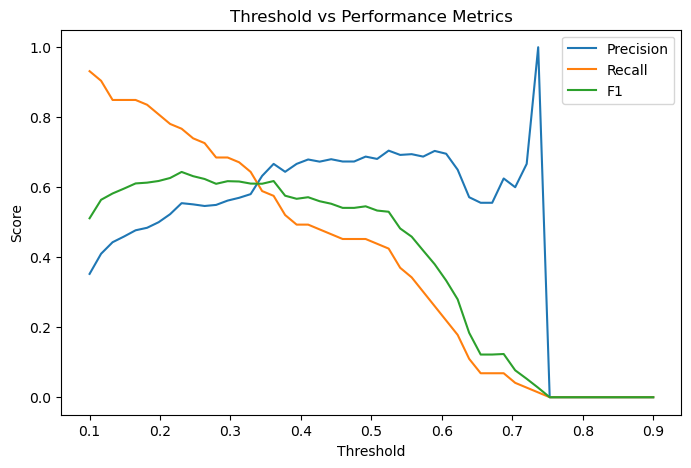

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Performance Metrics")
plt.legend()
plt.show()


### The threshold analysis reveals a clear precision-recall trade-off. The optimal F1 score is achieved around a threshold of approximately 0.25–0.30, indicating that the default 0.5 decision boundary is not optimal. Lower thresholds improve recall significantly, while higher thresholds increase precision at the expense of recall. The selection of threshold should therefore depend on the operational objective of the model.

### Since the dataset is moderately imbalanced, optimizing threshold rather than relying on the default 0.5 improves classification balance and operational reliability.

In [17]:
optimal_threshold = best_f1_row["threshold"]

joblib.dump(optimal_threshold, "optimal_threshold.pkl")


['optimal_threshold.pkl']